# Module 6 / Class 1 - Neural Network Fundamentals

This notebook uses small examples to explain inputs, weights, bias,
activation functions, matrix multiplication, and hidden layers. It
also includes the TensorFlow Playground findings from the assignment.

## 1. Setup

NumPy is used for the from-scratch perceptron. TensorFlow/Keras is
used for the tiny XOR network.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from IPython.display import Markdown, display

np.random.seed(42)
tf.keras.utils.set_random_seed(42)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Single Perceptron From Scratch

A perceptron calculates `activation(inputs dot weights + bias)`.
The step activation returns `1` when the score is non-negative,
otherwise it returns `0`.

In [2]:
class SimplePerceptron:
    def __init__(self, n_features, learning_rate=0.1, epochs=25):
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.learning_rate = learning_rate
        self.epochs = epochs

    def activation(self, score):
        return 1 if score >= 0 else 0

    def predict_one(self, inputs):
        score = np.dot(inputs, self.weights) + self.bias
        return self.activation(score)

    def predict(self, x_values):
        return np.array([self.predict_one(row) for row in x_values])

    def fit(self, x_values, y_values):
        for _ in range(self.epochs):
            for inputs, target in zip(x_values, y_values):
                prediction = self.predict_one(inputs)
                error = target - prediction
                self.weights += self.learning_rate * error * inputs
                self.bias += self.learning_rate * error

## 3. AND and OR Gates

AND and OR can be solved by one straight decision boundary, so one
perceptron is enough.

In [3]:
logic_inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1],
])

targets = {
    "AND": np.array([0, 0, 0, 1]),
    "OR": np.array([0, 1, 1, 1]),
}

rows = []
for gate_name, gate_targets in targets.items():
    model = SimplePerceptron(n_features=2)
    model.fit(logic_inputs, gate_targets)
    predictions = model.predict(logic_inputs)
    for inputs, target, prediction in zip(logic_inputs, gate_targets, predictions):
        rows.append({
            "gate": gate_name,
            "x1": inputs[0],
            "x2": inputs[1],
            "target": target,
            "prediction": prediction,
        })

pd.DataFrame(rows)

,gate,x1,x2,target,prediction
0,AND,0,0,0,0
1,AND,0,1,0,0
2,AND,1,0,0,0
3,AND,1,1,1,1
4,OR,0,0,0,0
5,OR,0,1,1,1
6,OR,1,0,1,1
7,OR,1,1,1,1


## 4. XOR Needs a Hidden Layer

XOR is not linearly separable. A single perceptron struggles because
it can only draw one straight line. A hidden layer lets the network
combine multiple simple boundaries.

In [4]:
xor_targets = np.array([0, 1, 1, 0])

xor_perceptron = SimplePerceptron(n_features=2)
xor_perceptron.fit(logic_inputs, xor_targets)

pd.DataFrame({
    "x1": logic_inputs[:, 0],
    "x2": logic_inputs[:, 1],
    "target": xor_targets,
    "single_perceptron_prediction": xor_perceptron.predict(logic_inputs),
})

,x1,x2,target,single_perceptron_prediction
0,0,0,0,1
1,0,1,1,1
2,1,0,1,0
3,1,1,0,0


In [5]:
xor_network = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(4, activation="tanh"),
    layers.Dense(1, activation="sigmoid"),
])

xor_network.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.1),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history = xor_network.fit(logic_inputs, xor_targets, epochs=1200, verbose=0)
probabilities = xor_network.predict(logic_inputs, verbose=0).reshape(-1)

pd.DataFrame({
    "x1": logic_inputs[:, 0],
    "x2": logic_inputs[:, 1],
    "target": xor_targets,
    "network_probability": np.round(probabilities, 3),
    "network_prediction": (probabilities >= 0.5).astype(int),
})

,x1,x2,target,network_probability,network_prediction
0,0,0,0,0.0,0
1,0,1,1,1.0,1
2,1,0,1,1.0,1
3,1,1,0,0.0,0


## 5. Matrix Multiplication Forward Pass

This is the same neural-network idea written with explicit matrices:
input matrix `X`, weight matrix `W`, bias vector `b`, and an
activation function.

In [6]:
def sigmoid(values):
    return 1 / (1 + np.exp(-values))

W1 = np.array([[20.0, -20.0],
               [20.0, -20.0]])
b1 = np.array([-10.0, 30.0])
W2 = np.array([[20.0],
               [20.0]])
b2 = np.array([-30.0])

hidden_scores = logic_inputs @ W1 + b1
hidden_outputs = sigmoid(hidden_scores)
final_scores = hidden_outputs @ W2 + b2
final_outputs = sigmoid(final_scores)

pd.DataFrame({
    "x1": logic_inputs[:, 0],
    "x2": logic_inputs[:, 1],
    "hidden_1": np.round(hidden_outputs[:, 0], 3),
    "hidden_2": np.round(hidden_outputs[:, 1], 3),
    "xor_output": np.round(final_outputs[:, 0], 3),
    "target": xor_targets,
})

,x1,x2,hidden_1,hidden_2,xor_output,target
0,0,0,0.0,1.0,0.0,0
1,0,1,1.0,1.0,1.0,1
2,1,0,1.0,1.0,1.0,1
3,1,1,1.0,0.0,0.0,0


## 6. Activation Functions

ReLU is common in hidden layers because it is simple and avoids tiny
gradients for positive values. Sigmoid is useful for binary
probability outputs.

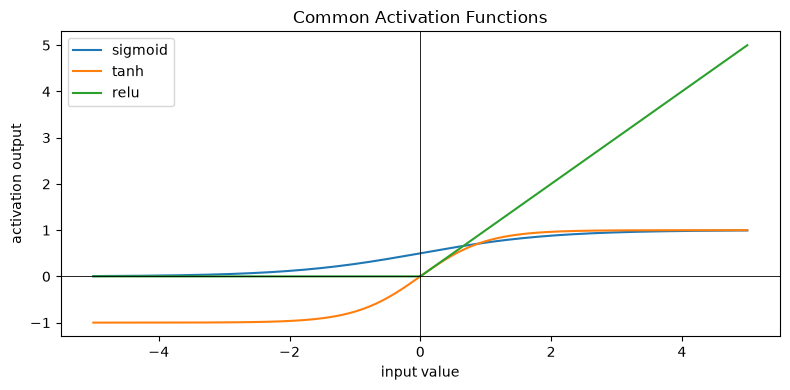

In [7]:
values = np.linspace(-5, 5, 200)
sigmoid_values = 1 / (1 + np.exp(-values))
tanh_values = np.tanh(values)
relu_values = np.maximum(0, values)

plt.figure(figsize=(8, 4))
plt.plot(values, sigmoid_values, label="sigmoid")
plt.plot(values, tanh_values, label="tanh")
plt.plot(values, relu_values, label="relu")
plt.axhline(0, color="black", linewidth=0.6)
plt.axvline(0, color="black", linewidth=0.6)
plt.title("Common Activation Functions")
plt.xlabel("input value")
plt.ylabel("activation output")
plt.legend()
plt.tight_layout()
plt.show()

## 7. TensorFlow Playground Findings

**Experiment 1 - XOR dataset**

- Configuration: 2 hidden layers, 4 neurons per layer, `tanh`
  activation, learning rate `0.03`.
- Result: The model converged after a few hundred epochs and
  separated the four XOR regions.
- Insight: XOR needs hidden layers because one straight line cannot
  separate the classes.

**Experiment 2 - Spiral dataset**

- Configuration: 2 hidden layers, 8 neurons per layer, `tanh`
  activation, learning rate `0.03`.
- Result: Training was slower than XOR, but the decision boundary
  gradually curved around the spiral.
- Insight: Harder shapes need more neurons and more training time.

**Experiment 3 - Activation functions**

- Configuration: I compared linear, sigmoid, tanh, and ReLU on
  non-linear data.
- Result: Linear activation could not model curved boundaries. Tanh
  and ReLU worked better.
- Insight: Activation functions are what make hidden layers useful
  for non-linear problems.

**Experiment 4 - Learning rate**

- Configuration: I tried low (`0.003`), medium (`0.03`), and high
  (`1.0`) learning rates.
- Result: The low rate learned slowly, the medium rate was stable,
  and the high rate jumped around.
- Insight: A good learning rate is large enough to learn quickly but
  not so large that training becomes unstable.